# PRE-PROCESSING PER LA CLUSTERIZZAZIONE


In [158]:
# ==========================================
#  CRIME CLUSTERING WITH DBSCAN
# ==========================================
# Librerie principali
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [159]:
# ------------------------------------------
# 1. IMPORTAZIONE E PULIZIA DATI
# ------------------------------------------
# Leggi il dataset CSV
df = pd.read_csv("CrimeData.csv")

# Rimozione righe con valori nulli e colonne non necessarie
df = df.drop(columns=['CrimeDate','Location', 'Neighborhood','Total Incidents'], axis=1)
df = df.dropna()

# Conversione ora
df['CrimeTime'] = pd.to_datetime(df['CrimeTime'], format='%H:%M:%S', errors='coerce').dt.hour

# Estrazione delle coordinate dalla colonna "Location 1" ed eliminazione colonna
df['Latitude'] = df['Location 1'].str.extract(r'\((.*),')[0].astype(float)
df['Longitude'] = df['Location 1'].str.extract(r', (.*)\)')[0].astype(float)
df = df.drop(columns=['Location 1'])

# sostituisco Inside->I e Outside->O
df['Inside/Outside'] = df['Inside/Outside'].replace({'Inside': 'I', 'Outside': 'O'})

# Uniforma stringhe (spazi, maiuscole)
df['Description'] = df['Description'].str.strip()
df['Inside/Outside'] = df['Inside/Outside'].map({'I':'Inside','O':'Outside'})
df['District'] = df['District'].replace({'Central':'CENTRAL', 'NORTHESTERN':'NORTHEASTERN', 'SOUTHESTERN':'SOUTHEASTERN', 'Gay Street': 'EASTERN'})
df['District'] = df['District'].str.strip()

# Crea fasce orarie (variabile ciclica "a blocchi")
bins  = [-0.1, 5, 11, 17, 23]
labs  = ['Night','Morning','Afternoon','Evening']
df['HourBin'] = pd.cut(df['CrimeTime'], bins=bins, labels=labs)

# ------------------------------------------
print("Totale righe dopo pulizia:", len(df))

df.head(10)


Totale righe dopo pulizia: 95077


,CrimeTime,CrimeCode,Description,Inside/Outside,Weapon,Post,District,Latitude,Longitude,HourBin
1,2.0,3CF,ROBBERY - COMMERCIAL,Inside,FIREARM,213.0,SOUTHEASTERN,39.28242,-76.59288,Night
5,3.0,4E,COMMON ASSAULT,Inside,HANDS,423.0,NORTHEASTERN,39.37070,-76.56709,Night
6,3.0,3CO,ROBBERY - COMMERCIAL,Outside,OTHER,933.0,SOUTHERN,39.28624,-76.64455,Night
9,8.0,4E,COMMON ASSAULT,Inside,HANDS,743.0,WESTERN,39.30340,-76.63842,Morning
11,9.0,4E,COMMON ASSAULT,Inside,HANDS,813.0,SOUTHWESTERN,39.30587,-76.67216,Morning
12,9.0,4E,COMMON ASSAULT,Inside,HANDS,312.0,EASTERN,39.29883,-76.61042,Morning
14,11.0,4E,COMMON ASSAULT,Inside,HANDS,444.0,NORTHEASTERN,39.32120,-76.53906,Morning
17,11.0,4B,AGG. ASSAULT,Outside,KNIFE,714.0,WESTERN,39.28810,-76.64888,Morning
19,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night
20,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night


# Selezione delle Feature

In [160]:
# Categorie per fare il profilo
cat_cols = ['Description','Weapon','HourBin']

# One-hot encoding (dummies)
dummies = pd.get_dummies(df[cat_cols], drop_first=False)

# Unità di aggregazione: il DISTRETTO 
agg_df = pd.concat([df[['District']], dummies], axis=1) \
           .groupby('District', as_index=True).mean()

print("Shape profili distretti:", agg_df.shape)
agg_df.head(10)


Shape profili distretti: (9, 17)


,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_HOMICIDE,Description_RAPE,Description_ROBBERY - CARJACKING,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Description_SHOOTING,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening
District,,,,,,,,,,,,,,,,,
CENTRAL,0.252615,0.519724,0.009790,0.017660,0.009214,0.028122,0.010846,0.134754,0.017276,0.178136,0.556867,0.118533,0.146463,0.254151,0.133122,0.262789,0.322872
EASTERN,0.303290,0.512351,0.020219,0.013066,0.006962,0.020410,0.009061,0.072580,0.042060,0.207630,0.547830,0.109776,0.134764,0.198760,0.147353,0.270291,0.321316
NORTHEASTERN,0.264003,0.503470,0.015002,0.014791,0.010585,0.035962,0.017035,0.116649,0.022503,0.229022,0.544339,0.089940,0.136698,0.203996,0.144339,0.275219,0.338941
NORTHERN,0.262744,0.462424,0.012316,0.018018,0.012316,0.047782,0.019386,0.142548,0.022466,0.252822,0.501654,0.098415,0.147109,0.226936,0.137530,0.264568,0.336184
NORTHWESTERN,0.297588,0.432924,0.020241,0.015827,0.016904,0.040159,0.015181,0.131029,0.030146,0.277778,0.471361,0.100129,0.150732,0.189169,0.154070,0.267011,0.339363
SOUTHEASTERN,0.263058,0.529741,0.006838,0.012935,0.006920,0.034108,0.011616,0.121437,0.013347,0.173010,0.565414,0.114928,0.146647,0.283984,0.118224,0.227797,0.349811
SOUTHERN,0.304488,0.496230,0.011955,0.016277,0.008001,0.029612,0.021979,0.084422,0.027037,0.192110,0.543038,0.096836,0.168015,0.246459,0.129115,0.242229,0.343204
SOUTHWESTERN,0.313799,0.462406,0.021893,0.015812,0.012716,0.026758,0.016807,0.087019,0.042791,0.256081,0.502433,0.094317,0.147169,0.186754,0.146948,0.282508,0.319107
WESTERN,0.328025,0.468300,0.023992,0.014906,0.011434,0.017152,0.011026,0.076161,0.049005,0.229301,0.508116,0.103114,0.159469,0.180398,0.149362,0.283920,0.313323


# Standardizzazione delle feature e Scelta di K


In [161]:
# Standardizzazione delle feature
X = agg_df.values  # solo le percentuali
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

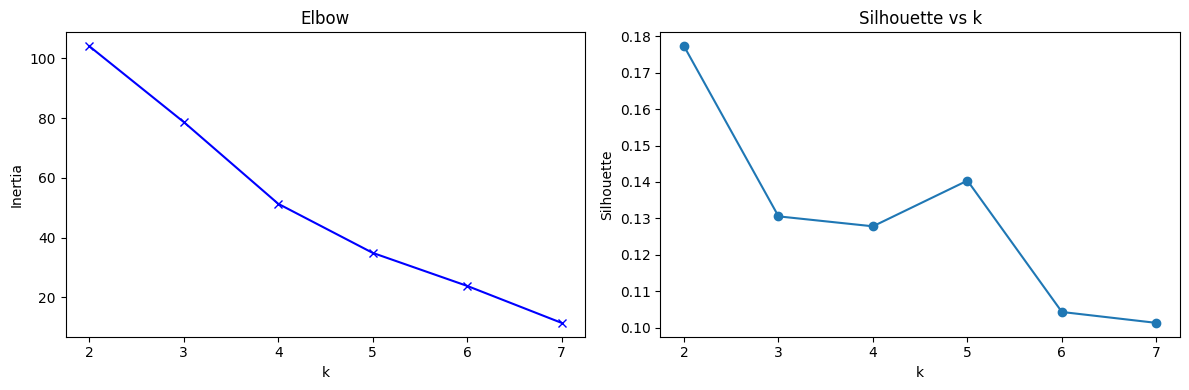

In [162]:
# Elbow Method per determinare il valore ottimale di k
distorsioni = []
silhouettes = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    km.fit(X_scaled)
    distorsioni.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, distorsioni, 'bx-')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k')
plt.tight_layout(); plt.show()

# Creazione CLuster

In [163]:
# === STEP 1: Fit finale di KMeans e assegnazione ai distretti ===
k_opt = 4  # <-- imposta dopo aver visto i grafici
kmeans = KMeans(n_clusters=k_opt, n_init='auto', random_state=0)
labels = kmeans.fit_predict(X_scaled)


In [164]:
# Risultati
clustered = agg_df.copy()
clustered['cluster'] = labels
# Quanti distretti per cluster?
print(clustered['cluster'].value_counts().sort_index())
clustered.sort_values('cluster').head()

cluster
0    1
1    2
2    3
3    3
Name: count, dtype: int64


,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_HOMICIDE,Description_RAPE,Description_ROBBERY - CARJACKING,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Description_SHOOTING,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening,cluster
District,,,,,,,,,,,,,,,,,,
NORTHWESTERN,0.297588,0.432924,0.020241,0.015827,0.016904,0.040159,0.015181,0.131029,0.030146,0.277778,0.471361,0.100129,0.150732,0.189169,0.154070,0.267011,0.339363,0
CENTRAL,0.252615,0.519724,0.009790,0.017660,0.009214,0.028122,0.010846,0.134754,0.017276,0.178136,0.556867,0.118533,0.146463,0.254151,0.133122,0.262789,0.322872,1
SOUTHEASTERN,0.263058,0.529741,0.006838,0.012935,0.006920,0.034108,0.011616,0.121437,0.013347,0.173010,0.565414,0.114928,0.146647,0.283984,0.118224,0.227797,0.349811,1
NORTHEASTERN,0.264003,0.503470,0.015002,0.014791,0.010585,0.035962,0.017035,0.116649,0.022503,0.229022,0.544339,0.089940,0.136698,0.203996,0.144339,0.275219,0.338941,2
NORTHERN,0.262744,0.462424,0.012316,0.018018,0.012316,0.047782,0.019386,0.142548,0.022466,0.252822,0.501654,0.098415,0.147109,0.226936,0.137530,0.264568,0.336184,2


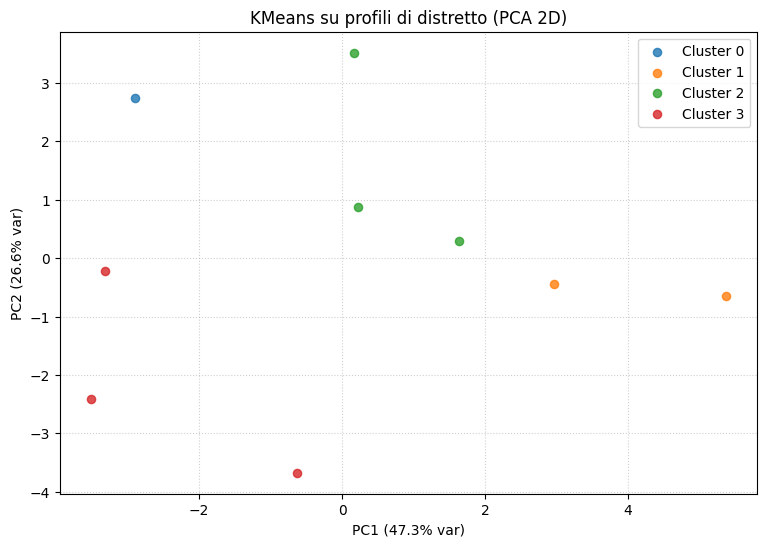

In [165]:
# === STEP 2: PCA per visualizzare in 2D ===
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
for c in np.unique(labels):
    plt.scatter(
        X_pca[labels == c, 0],
        X_pca[labels == c, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {c}'
    )
plt.title('KMeans su profili di distretto (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [166]:
# === STEP 3: Centroidi e feature più alte per cluster ===
# Centroidi nella scala standardizzata e riportati alle percentuali originali
centers_unscaled = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=agg_df.columns,
    index=[f'Cluster {i}' for i in range(k_opt)]
)

# Top feature (le più “alte”) per ogni cluster
for c in centers_unscaled.index:
    print(f'\n=== {c}: feature dominanti ===')
    print(
        centers_unscaled.loc[c]
        .sort_values(ascending=False)
        .head(10)
        .round(3)
    )



=== Cluster 0: feature dominanti ===
Weapon_HANDS                    0.471
Description_COMMON ASSAULT      0.433
HourBin_Evening                 0.339
Description_AGG. ASSAULT        0.298
Weapon_FIREARM                  0.278
HourBin_Afternoon               0.267
HourBin_Night                   0.189
HourBin_Morning                 0.154
Weapon_OTHER                    0.151
Description_ROBBERY - STREET    0.131
Name: Cluster 0, dtype: float64

=== Cluster 1: feature dominanti ===
Weapon_HANDS                    0.561
Description_COMMON ASSAULT      0.525
HourBin_Evening                 0.336
HourBin_Night                   0.269
Description_AGG. ASSAULT        0.258
HourBin_Afternoon               0.245
Weapon_FIREARM                  0.176
Weapon_OTHER                    0.147
Description_ROBBERY - STREET    0.128
HourBin_Morning                 0.126
Name: Cluster 1, dtype: float64

=== Cluster 2: feature dominanti ===
Weapon_HANDS                    0.530
Description_COMMON ASSAU

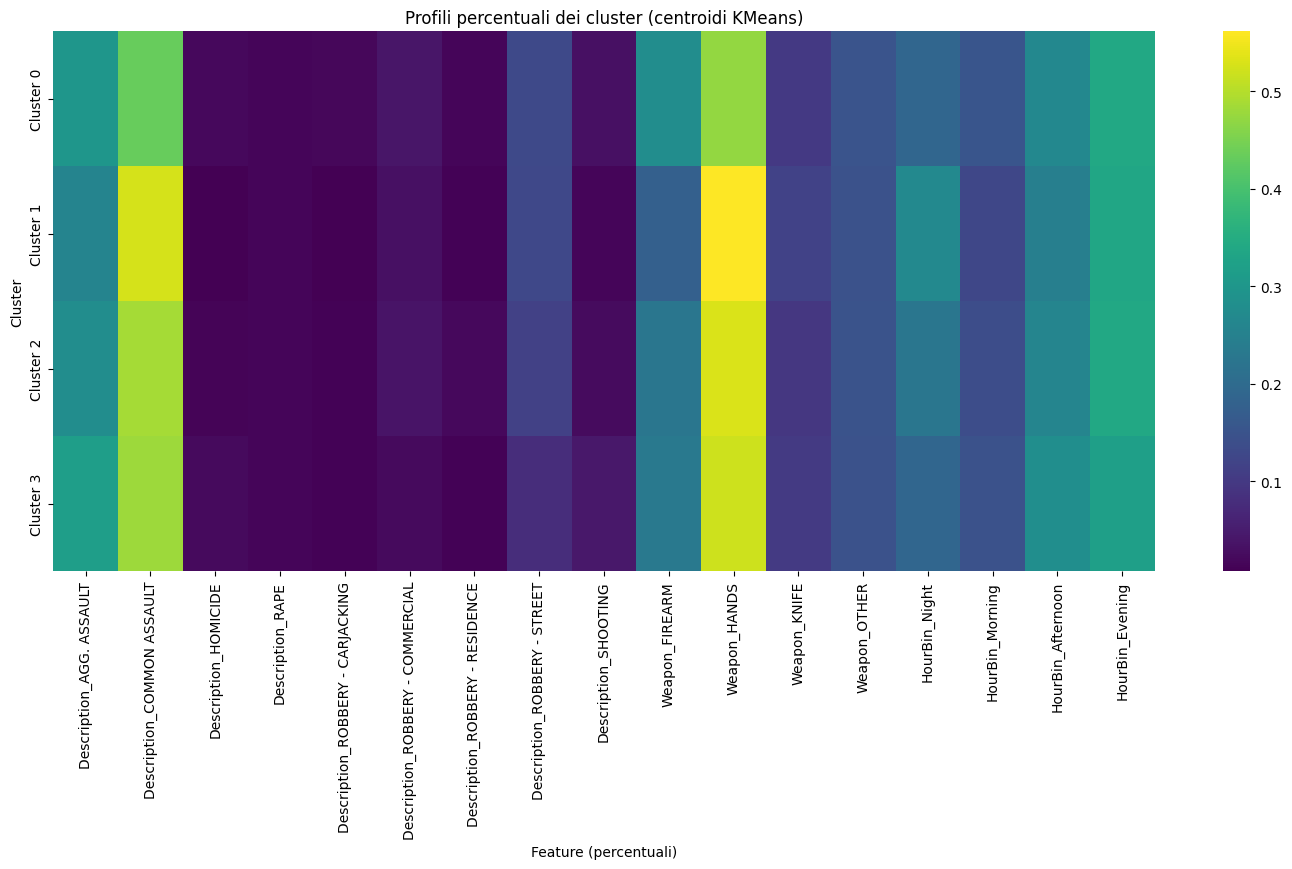

In [167]:
# === STEP 4: Heatmap dei centroidi per confronto rapido ===
plt.figure(figsize=(min(16, 0.5*len(agg_df.columns)+6), 1.2*k_opt+4))
sns.heatmap(
    centers_unscaled,
    cmap='viridis',
    annot=False,
    cbar=True
)
plt.title('Profili percentuali dei cluster (centroidi KMeans)')
plt.xlabel('Feature (percentuali)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


In [168]:
# === STEP 5: Mappatura distretto-cluster ===
distretto_cluster = clustered[['cluster']].reset_index().rename(columns={'index':'District'})
distretto_cluster = distretto_cluster.sort_values(['cluster','District'])
distretto_cluster.head(20)


,District,cluster
4,NORTHWESTERN,0
0,CENTRAL,1
5,SOUTHEASTERN,1
2,NORTHEASTERN,2
3,NORTHERN,2
6,SOUTHERN,2
1,EASTERN,3
7,SOUTHWESTERN,3
8,WESTERN,3


In [169]:
# === STEP 6 (opzionale): LIFT rispetto alla media globale ===
global_mean = agg_df.mean()

lift = centers_unscaled.copy()
for col in lift.columns:
    baseline = global_mean[col] if global_mean[col] != 0 else 1e-9
    lift[col] = lift[col] / baseline  # >1 = sopra la media globale

for c in lift.index:
    print(f'\n=== {c}: feature con lift più alto ===')
    print(
        lift.loc[c]
        .sort_values(ascending=False)
        .head(10)
        .round(2)
    )



=== Cluster 0: feature con lift più alto ===
Description_ROBBERY - CARJACKING    1.60
Description_ROBBERY - COMMERCIAL    1.29
Description_HOMICIDE                1.28
Weapon_FIREARM                      1.25
Description_ROBBERY - STREET        1.22
HourBin_Morning                     1.10
Description_AGG. ASSAULT            1.03
Description_ROBBERY - RESIDENCE     1.03
HourBin_Evening                     1.02
Description_RAPE                    1.02
Name: Cluster 0, dtype: float64

=== Cluster 1: feature con lift più alto ===
HourBin_Night                       1.23
Description_ROBBERY - STREET        1.19
Weapon_KNIFE                        1.13
Description_COMMON ASSAULT          1.08
Weapon_HANDS                        1.07
HourBin_Evening                     1.01
Description_ROBBERY - COMMERCIAL    1.00
Description_RAPE                    0.99
Weapon_OTHER                        0.99
HourBin_Afternoon                   0.93
Name: Cluster 1, dtype: float64

=== Cluster 2: feature 